# Feature Ablation Study — v2 (camera-ready revision)

Rerun of `feature_ablation_study.ipynb` addressing the reviewer comments. Same data, same
speaker-grouped CV, same models and hyperparameters; what changed:

| Change | Why (review) |
|---|---|
| **Metadata is an explicit axis.** Every feature family is run with *no metadata* and with *age + sex*. | g1YR: the old "MFDFA only" row silently included age and sex. |
| **Metadata-only baselines**: age only, sex only, age + sex. | g1YR: is the classifier just learning demographics? |
| **Configurations without MFDFA** (OpenSMILE, NeuroKit2, OpenSMILE + NeuroKit2). | Jfiw: MFDFA was present in all five old rows. |
| **Age × sex matched evaluation.** | g1YR: demographic matching / stratification. |
| **Per-fold scores kept**: mean ± SD and 95% CI over folds. | g1YR: report per-fold variation / CIs. |
| **Fixed-model results** alongside best-model-per-config. | g1YR: clarify model selection (picking the best of 4 models on test folds is optimistic). |
| **Unicode fix for disease labels** (`FIX_UNICODE`). | The raw labels use decomposed umlauts (`o` + U+0308), so the old map silently dropped *Phonationsknötchen* (17 samples) as "unmapped". |
| **Protocol log** of every filtering / downsampling step. | g1YR: explain filtering and downsampling precisely. |
| **No collinearity filter** (`USE_COLLINEARITY_FILTER = False`): every family uses all its features (MFDFA 12, eGeMAPS 88, NeuroKit2 7). | The paper describes 107 features; the filter (not described) left only 4 of 12 MFDFA descriptors. |
| **Matching = nearest neighbour**, same sex, ±2 years, cases matched against the full (not downsampled) healthy pool. | Same matched sets as `model_training_v8.ipynb`. |

Feature tables are read **directly from the cached CSVs** in `data/processed/` — no rebuild can be triggered
(the WAVs no longer exist). Set `FIX_UNICODE = False` to reproduce the old notebook's sample set
(old best row, MFDFA + OpenSMILE + age + sex with LightGBM, was F1 0.878).

## 1 — Setup

In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

## 2 — Configuration (identical to v1 unless noted)

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

SELECTED_TOKEN = 'a_n'
MIN_SAMPLES_PER_CLASS = 50
BALANCE_HEALTHY = True
EXCLUDE_MIXED_BINARY_SPEAKERS = True

N_SPLITS = 5
THRESHOLD_GRID = np.linspace(0.35, 0.65, 11)
BINARY_THRESHOLD_OBJECTIVE = 'accuracy'
COLLINEARITY_THRESHOLD = 0.85
USE_COLLINEARITY_FILTER = False   # NEW (camera-ready): all described features are used

FIX_UNICODE = True          # NEW: NFC-normalise pathology labels before mapping
MATCH_CALIPER_YEARS = 2.0   # NEW: nearest-neighbour age matching, same sex, within ± this many years

DISEASE_GROUP_MAP = {
    'Morbus Parkinson': 'Neurological',
    'Rekurrensparese': 'Neurological',
    'Spasmodische Dysphonie': 'Neurological',
    'Phonationsknötchen': 'Structural',
    'Stimmlippenpolyp': 'Structural',
    'Laryngitis': 'Structural',
}

ROOT = Path('..')
FEAT_DIR = ROOT / 'data' / 'processed' / 'features'
MANIFEST_PATH = ROOT / 'data' / 'processed' / 'manifests' / 'dataset_manifest.csv'
OUT_DIR = ROOT / 'results' / 'ablation_v2'
FIG_DIR = ROOT / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

nfc = lambda s: unicodedata.normalize('NFC', s) if isinstance(s, str) else s
DISEASE_GROUP_MAP = {nfc(k): v for k, v in DISEASE_GROUP_MAP.items()}

## 3 — Load cached feature tables (read-only)

In [3]:
def _read(name):
    return pd.read_csv(FEAT_DIR / f'{name}.csv').drop_duplicates(subset=['sample_key'])

core_df = _read('sample_core')
multifractal_df = _read('multifractal_features')
opensmile_df = _read('opensmile_features')
neurokit2_df = _read('neurokit2_features')

manifest = pd.read_csv(MANIFEST_PATH, usecols=['sample_key', 'birth_date', 'recording_date'], low_memory=False)
manifest = manifest.drop_duplicates(subset=['sample_key'])

df_full = (core_df
           .merge(multifractal_df, on='sample_key', how='left')
           .merge(opensmile_df, on='sample_key', how='left')
           .merge(neurokit2_df, on='sample_key', how='left')
           .merge(manifest, on='sample_key', how='left'))

df_full = df_full.copy()
bd = pd.to_datetime(df_full['birth_date'], errors='coerce')
rd = pd.to_datetime(df_full['recording_date'], errors='coerce')
df_full['age'] = ((rd - bd).dt.days / 365.25).round(1)
df_full = df_full.drop(columns=['birth_date', 'recording_date'])

for col in ['feature_status', 'mf_status', 'opensmile_status', 'nk_status']:
    df_full = df_full[df_full[col].isin(['ok', 'partial_failure'] if col == 'feature_status' else ['ok'])]

if FIX_UNICODE:
    df_full['pathology_de'] = df_full['pathology_de'].map(nfc)

print(f'Merged: {df_full.shape}  |  speakers: {df_full.speaker_id.nunique()}  |  age missing: {df_full.age.isna().sum()}')

Merged: (1656, 134)  |  speakers: 1355  |  age missing: 0


## 4 — Targets & filters, with a protocol log

In [4]:
protocol = []
def log(step, n_before, n_after, detail=''):
    protocol.append({'step': step, 'samples_before': n_before, 'samples_after': n_after, 'detail': detail})

df = df_full.copy()
log('Start: a_n recordings with all feature families extracted', len(df), len(df))

print('Samples per SVD pathology folder (a_n):')
display(df['pathology_de'].value_counts().to_frame('n'))

raw_target = df['pathology_de'].astype(str).str.strip()
mapped = raw_target.map(DISEASE_GROUP_MAP)
healthy = df['is_healthy'].astype(bool)
unmapped = mapped.isna() & ~healthy
n0 = len(df)
dropped = raw_target[unmapped].value_counts().to_dict()
df = df[~unmapped].copy(); mapped = mapped[~unmapped]
log('Drop pathologies outside the two disease groups', n0, len(df), str(dropped))

mapped.loc[df['is_healthy'].astype(bool)] = 'healthy'
df['target_label'] = mapped.astype(str)
target_col = 'target_label'

if EXCLUDE_MIXED_BINARY_SPEAKERS:
    n0 = len(df)
    g = df.groupby(df['speaker_id'].astype(str))['is_healthy'].nunique()
    bad = set(g[g > 1].index)
    df = df[~df['speaker_id'].astype(str).isin(bad)].copy()
    log('Drop speakers with both healthy and pathological recordings', n0, len(df), f'{len(bad)} speakers')

n0 = len(df)
vc = df[target_col].value_counts()
small = vc[vc < MIN_SAMPLES_PER_CLASS].index.tolist()
df = df[~df[target_col].isin(small)].copy()
log(f'Drop target classes with < {MIN_SAMPLES_PER_CLASS} samples', n0, len(df), str(small) if small else 'none')

healthy_full = df[df['is_healthy'].astype(bool)].copy()   # full healthy pool, before downsampling (for matching)

if BALANCE_HEALTHY:
    n0 = len(df)
    n_patho = int((~df['is_healthy'].astype(bool)).sum())
    hm = df['is_healthy'].astype(bool)
    if hm.sum() > n_patho:
        drop_idx = df[hm].sample(n=int(hm.sum()) - n_patho, random_state=RANDOM_SEED).index
        df = df.drop(drop_idx).copy()
    log('Randomly downsample healthy to the pathological count (seed 42)', n0, len(df))

protocol_df = pd.DataFrame(protocol)
display(protocol_df)

print('\nFinal composition:')
comp = (df.groupby([target_col, 'pathology_de'])
          .agg(samples=('sample_key', 'size'), speakers=('speaker_id', 'nunique')))
display(comp)
print(f'Total: {len(df)} samples, {df.speaker_id.nunique()} speakers')

Samples per SVD pathology folder (a_n):


,n
pathology_de,
healthy,687
Hyperfunktionelle Dysphonie,213
Rekurrensparese,213
Laryngitis,140
Funktionelle Dysphonie,112
Psychogene Dysphonie,91
Reinke Ödem,68
Spasmodische Dysphonie,64
Stimmlippenpolyp,45


,step,samples_before,samples_after,detail
0,Start: a_n recordings with all feature familie...,1656,1656,
1,Drop pathologies outside the two disease groups,1656,1167,"{'Hyperfunktionelle Dysphonie': 213, 'Funktion..."
2,Drop speakers with both healthy and pathologic...,1167,1163,2 speakers
3,Drop target classes with < 50 samples,1163,1163,none
4,Randomly downsample healthy to the pathologica...,1163,956,



Final composition:


samples  speakers
target_label pathology_de                             
Neurological Morbus Parkinson              1         1
             Rekurrensparese             212       155
             Spasmodische Dysphonie       64        12
Structural   Laryngitis                  140       128
             Phonationsknötchen           17        17
             Stimmlippenpolyp             44        39
healthy      healthy                     478       477

Total: 956 samples, 820 speakers


## 5 — Demographics by class

If age or sex differ strongly between classes, metadata alone can separate them. This table goes into the paper's dataset description.

,class,n,age_mean,age_sd,age_median,female_pct
0,healthy,478,27.1,10.9,22.3,63.6
1,pathological,478,54.0,15.0,56.5,56.1


Binary — age Mann-Whitney p = 5.29e-111;  sex chi2 p = 2.09e-02


,class,n,age_mean,age_sd,age_median,female_pct
0,Neurological,277,57.0,14.1,60.1,65.0
1,Structural,201,49.9,15.2,51.1,43.8


Disease groups — age Mann-Whitney p = 3.26e-07;  sex chi2 p = 6.27e-06


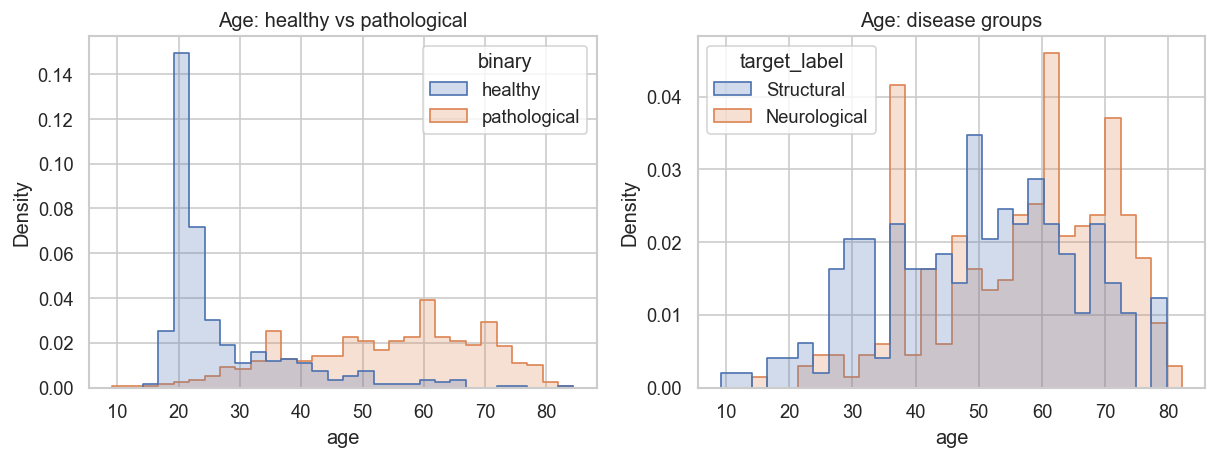

In [5]:
def demo_table(d, label_col):
    rows = []
    for lab, g in d.groupby(label_col):
        rows.append({'class': lab, 'n': len(g),
                     'age_mean': g.age.mean(), 'age_sd': g.age.std(),
                     'age_median': g.age.median(),
                     'female_pct': 100 * (g.sex == 'w').mean()})
    return pd.DataFrame(rows).round(1)

d_bin = df.assign(binary=np.where(df.is_healthy.astype(bool), 'healthy', 'pathological'))
display(demo_table(d_bin, 'binary'))
u = stats.mannwhitneyu(d_bin.loc[d_bin.binary == 'healthy', 'age'], d_bin.loc[d_bin.binary != 'healthy', 'age'])
chi = stats.chi2_contingency(pd.crosstab(d_bin.binary, d_bin.sex))
print(f'Binary — age Mann-Whitney p = {u.pvalue:.2e};  sex chi2 p = {chi.pvalue:.2e}')

d_multi = df[~df.is_healthy.astype(bool)]
display(demo_table(d_multi, target_col))
labs = sorted(d_multi[target_col].unique())
u = stats.mannwhitneyu(*[d_multi.loc[d_multi[target_col] == l, 'age'] for l in labs])
chi = stats.chi2_contingency(pd.crosstab(d_multi[target_col], d_multi.sex))
print(f'Disease groups — age Mann-Whitney p = {u.pvalue:.2e};  sex chi2 p = {chi.pvalue:.2e}')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(d_bin, x='age', hue='binary', bins=30, element='step', stat='density', common_norm=False, ax=ax[0])
ax[0].set_title('Age: healthy vs pathological')
sns.histplot(d_multi, x='age', hue=target_col, bins=30, element='step', stat='density', common_norm=False, ax=ax[1])
ax[1].set_title('Age: disease groups')
plt.show()

## 6 — Feature families and ablation configurations

In [6]:
mf_cols = [c for c in df.columns if c.startswith('mf_') and c not in ('mf_status', 'mf_error', 'mf_num_scales', 'mf_num_q')]
os_cols = [c for c in df.columns if c.startswith('os_') and c not in ('opensmile_status', 'opensmile_error')]
nk_cols = [c for c in df.columns if c.startswith('nk_') and c not in ('nk_status', 'nk_error')]
mf_cols = [c for c in mf_cols if pd.api.types.is_numeric_dtype(df[c])]
os_cols = [c for c in os_cols if pd.api.types.is_numeric_dtype(df[c])]
nk_cols = [c for c in nk_cols if pd.api.types.is_numeric_dtype(df[c])]
print(f'MFDFA {len(mf_cols)} | OpenSMILE {len(os_cols)} | NeuroKit2 {len(nk_cols)}')

FAMILIES = {'MFDFA': mf_cols, 'OpenSMILE': os_cols, 'NeuroKit2': nk_cols}

# (label, families, metadata)   metadata in {'none', 'age', 'sex', 'age+sex'}
ABLATIONS = [
    # metadata-only baselines
    ('Age only',                         [],                                  'age'),
    ('Sex only',                         [],                                  'sex'),
    ('Age + Sex',                        [],                                  'age+sex'),
    # signal features only (no metadata)
    ('MFDFA',                            ['MFDFA'],                           'none'),
    ('OpenSMILE',                        ['OpenSMILE'],                       'none'),
    ('NeuroKit2',                        ['NeuroKit2'],                       'none'),
    ('MFDFA + OpenSMILE',                ['MFDFA', 'OpenSMILE'],              'none'),
    ('MFDFA + NeuroKit2',                ['MFDFA', 'NeuroKit2'],              'none'),
    ('OpenSMILE + NeuroKit2',            ['OpenSMILE', 'NeuroKit2'],          'none'),
    ('MFDFA + OpenSMILE + NeuroKit2',    ['MFDFA', 'OpenSMILE', 'NeuroKit2'], 'none'),
    # signal features + age + sex
    ('MFDFA',                            ['MFDFA'],                           'age+sex'),
    ('OpenSMILE',                        ['OpenSMILE'],                       'age+sex'),
    ('MFDFA + OpenSMILE',                ['MFDFA', 'OpenSMILE'],              'age+sex'),
    ('MFDFA + NeuroKit2',                ['MFDFA', 'NeuroKit2'],              'age+sex'),
    ('OpenSMILE + NeuroKit2',            ['OpenSMILE', 'NeuroKit2'],          'age+sex'),
    ('MFDFA + OpenSMILE + NeuroKit2',    ['MFDFA', 'OpenSMILE', 'NeuroKit2'], 'age+sex'),
    # v1 "MFDFA + OpenSMILE - Age" row, which still contained sex
    ('MFDFA + OpenSMILE',                ['MFDFA', 'OpenSMILE'],              'sex'),
]

META_LABEL = {'none': 'no metadata', 'age': 'age', 'sex': 'sex', 'age+sex': 'age + sex'}

def config_columns(families, metadata, data):
    num = [c for f in families for c in FAMILIES[f]]
    # optional collinearity filter (v1 behaviour; off for the camera-ready runs)
    if USE_COLLINEARITY_FILTER and len(num) > 1:
        corr = data[num].corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
        drop = [c for c in upper.columns if (upper[c] > COLLINEARITY_THRESHOLD).any()]
        num = [c for c in num if c not in drop]
    if 'age' in metadata:
        num = num + ['age']
    cat = ['sex'] if 'sex' in metadata else []
    return num, cat

for label, fams, meta in ABLATIONS:
    n, c = config_columns(fams, meta, df)
    print(f'{label:32s} [{META_LABEL[meta]:11s}] -> {len(n)} numeric + {len(c)} categorical')

MFDFA 12 | OpenSMILE 88 | NeuroKit2 7
Age only                         [age        ] -> 1 numeric + 0 categorical
Sex only                         [sex        ] -> 0 numeric + 1 categorical
Age + Sex                        [age + sex  ] -> 1 numeric + 1 categorical
MFDFA                            [no metadata] -> 12 numeric + 0 categorical
OpenSMILE                        [no metadata] -> 88 numeric + 0 categorical
NeuroKit2                        [no metadata] -> 7 numeric + 0 categorical
MFDFA + OpenSMILE                [no metadata] -> 100 numeric + 0 categorical
MFDFA + NeuroKit2                [no metadata] -> 19 numeric + 0 categorical
OpenSMILE + NeuroKit2            [no metadata] -> 95 numeric + 0 categorical
MFDFA + OpenSMILE + NeuroKit2    [no metadata] -> 107 numeric + 0 categorical
MFDFA                            [age + sex  ] -> 13 numeric + 1 categorical
OpenSMILE                        [age + sex  ] -> 89 numeric + 1 categorical
MFDFA + OpenSMILE                [age + 

## 7 — Evaluation harness

Same as v1 (speaker-grouped stratified 5-fold, threshold tuned on the *training* fold for binary),
but per-fold scores are kept. 95% CIs use the t-distribution over the 5 fold scores; they reflect
fold-to-fold variation only, not the variance of a new dataset.

In [7]:
TREE_MODELS = (RandomForestClassifier, XGBClassifier, LGBMClassifier)

def build_preprocessors(num_cols, cat_cols):
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    lin_num = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value=0.0, add_indicator=True)),
                        ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
                        ('variance', VarianceThreshold(threshold=0.0))])
    tree_t, lin_t = [], []
    if num_cols:
        tree_t.append(('num', 'passthrough', num_cols)); lin_t.append(('num', lin_num, num_cols))
    if cat_cols:
        tree_t.append(('cat', cat_pipe, cat_cols)); lin_t.append(('cat', cat_pipe, cat_cols))
    mk = lambda t: ColumnTransformer(t, remainder='drop').set_output(transform='pandas')
    return mk(tree_t), mk(lin_t)

def make_pipe(model, tree_prep, lin_prep):
    return Pipeline([('prep', clone(tree_prep if isinstance(model, TREE_MODELS) else lin_prep)),
                     ('model', clone(model))])

def sample_weights(y_enc):
    classes = np.unique(y_enc)
    w = compute_class_weight('balanced', classes=classes, y=y_enc)
    m = dict(zip(classes, w))
    return np.array([m[v] for v in y_enc], dtype=float)

def cv_binary(model, X, y, groups, tree_prep, lin_prep):
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    rows = []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
        pipe = make_pipe(model, tree_prep, lin_prep)
        pipe.fit(X.iloc[tr], y.iloc[tr])
        p_tr = pipe.predict_proba(X.iloc[tr])[:, 1]
        best_thr, best = 0.5, -1.0
        for thr in THRESHOLD_GRID:
            pr = (p_tr >= thr).astype(int)
            s = accuracy_score(y.iloc[tr], pr) if BINARY_THRESHOLD_OBJECTIVE == 'accuracy' else balanced_accuracy_score(y.iloc[tr], pr)
            if s > best:
                best, best_thr = s, float(thr)
        pred = (pipe.predict_proba(X.iloc[te])[:, 1] >= best_thr).astype(int)
        yt = y.iloc[te]
        rows.append({'fold': fold, 'accuracy': accuracy_score(yt, pred),
                     'balanced_accuracy': balanced_accuracy_score(yt, pred),
                     'f1_macro': f1_score(yt, pred, average='macro', zero_division=0)})
    return rows

def cv_multiclass(model, X, y, groups, tree_prep, lin_prep):
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    rows = []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
        le = LabelEncoder()
        ytr = le.fit_transform(y.iloc[tr].astype(str)); yte = le.transform(y.iloc[te].astype(str))
        pipe = make_pipe(model, tree_prep, lin_prep)
        pipe.fit(X.iloc[tr], ytr, model__sample_weight=sample_weights(ytr))
        pred = pipe.predict(X.iloc[te])
        rows.append({'fold': fold, 'accuracy': accuracy_score(yte, pred),
                     'balanced_accuracy': balanced_accuracy_score(yte, pred),
                     'f1_macro': f1_score(yte, pred, average='macro', zero_division=0)})
    return rows

def summarise(fold_df, keys):
    def agg(g):
        out = {}
        for m in ['accuracy', 'balanced_accuracy', 'f1_macro']:
            v = g[m].to_numpy(); n = len(v)
            mean, sd = v.mean(), v.std(ddof=1)
            h = stats.t.ppf(0.975, n - 1) * sd / np.sqrt(n)
            out[f'{m}_mean'] = mean; out[f'{m}_sd'] = sd
            out[f'{m}_ci_lo'] = mean - h; out[f'{m}_ci_hi'] = mean + h
        return pd.Series(out)
    return fold_df.groupby(keys, sort=False).apply(agg, include_groups=False).reset_index()

## 8 — Models (unchanged from v1)

In [8]:
binary_models = {
    'LogReg': LogisticRegression(max_iter=3000, class_weight='balanced', C=1.0, random_state=RANDOM_SEED),
    'RandomForest': RandomForestClassifier(n_estimators=800, max_depth=None, min_samples_leaf=2,
                                           class_weight='balanced_subsample', random_state=RANDOM_SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=63, min_child_samples=15,
                               subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                               random_state=RANDOM_SEED, n_jobs=-1, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=700, learning_rate=0.03, max_depth=6, subsample=0.8,
                             colsample_bytree=0.8, min_child_weight=3, reg_alpha=1.0, reg_lambda=2.0,
                             random_state=RANDOM_SEED, n_jobs=-1, eval_metric='logloss'),
}
multi_models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced_subsample',
                                           random_state=RANDOM_SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, class_weight='balanced',
                               random_state=RANDOM_SEED, n_jobs=-1, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                             colsample_bytree=0.8, min_child_weight=3, reg_alpha=1.0, reg_lambda=2.0,
                             random_state=RANDOM_SEED, n_jobs=-1, eval_metric='mlogloss'),
}

## 9 — Run the ablation (full filtered set)

In [9]:
def run_ablation(data, ablations, tag, run_multi=True):
    y_bin = data['is_healthy'].astype(int)
    y_multi = data[target_col].astype(str)
    groups = data['speaker_id'].astype(str)
    patho = y_bin == 0
    b_rows, m_rows = [], []
    for label, fams, meta in ablations:
        num, cat = config_columns(fams, meta, data)
        X = data[num + cat]
        tp, lp = build_preprocessors(num, cat)
        for name, model in binary_models.items():
            for r in cv_binary(model, X, y_bin, groups, tp, lp):
                b_rows.append({'setting': tag, 'config': label, 'metadata': META_LABEL[meta], 'model': name, **r})
        if run_multi:
            for name, model in multi_models.items():
                for r in cv_multiclass(model, X[patho], y_multi[patho], groups[patho], tp, lp):
                    m_rows.append({'setting': tag, 'config': label, 'metadata': META_LABEL[meta], 'model': name, **r})
        print(f'  done: {label} [{META_LABEL[meta]}]')
    return pd.DataFrame(b_rows), pd.DataFrame(m_rows)

bin_folds, multi_folds = run_ablation(df, ABLATIONS, 'full')

  done: Age only [age]
  done: Sex only [sex]
  done: Age + Sex [age + sex]
  done: MFDFA [no metadata]
  done: OpenSMILE [no metadata]
  done: NeuroKit2 [no metadata]
  done: MFDFA + OpenSMILE [no metadata]
  done: MFDFA + NeuroKit2 [no metadata]
  done: OpenSMILE + NeuroKit2 [no metadata]
  done: MFDFA + OpenSMILE + NeuroKit2 [no metadata]
  done: MFDFA [age + sex]
  done: OpenSMILE [age + sex]
  done: MFDFA + OpenSMILE [age + sex]
  done: MFDFA + NeuroKit2 [age + sex]
  done: OpenSMILE + NeuroKit2 [age + sex]
  done: MFDFA + OpenSMILE + NeuroKit2 [age + sex]
  done: MFDFA + OpenSMILE [sex]


## 10 — Results

**Best model per configuration** picks, for each row, whichever of the 4 (binary) or 3 (multi-class) models
scored highest on the test folds. That is a small optimistic selection, so the **fixed-model** tables report
one model for every row (LogReg and LightGBM for binary, RandomForest for multi-class). Report the
fixed-model table in the paper, or say explicitly that the model was selected on CV performance.

In [10]:
KEYS = ['setting', 'config', 'metadata', 'model']
bin_sum = summarise(bin_folds, KEYS)
multi_sum = summarise(multi_folds, KEYS)

def fmt(d, m='f1_macro'):
    return d.assign(**{f'{m} (mean ± SD)': d[f'{m}_mean'].map('{:.3f}'.format) + ' ± ' + d[f'{m}_sd'].map('{:.3f}'.format),
                       f'{m} 95% CI': '[' + d[f'{m}_ci_lo'].map('{:.3f}'.format) + ', ' + d[f'{m}_ci_hi'].map('{:.3f}'.format) + ']'})

def best_per_config(s):
    return (s.sort_values('f1_macro_mean', ascending=False)
             .drop_duplicates(subset=['setting', 'config', 'metadata']))

order = {'no metadata': 0, 'age': 1, 'sex': 2, 'age + sex': 3}
def show(s, title, cols=('config', 'metadata', 'model')):
    s = s.assign(_o=s.metadata.map(order)).sort_values(['_o', 'f1_macro_mean'], ascending=[True, False])
    s = fmt(fmt(s, 'balanced_accuracy'), 'f1_macro')
    print(title)
    display(s[list(cols) + ['balanced_accuracy (mean ± SD)', 'f1_macro (mean ± SD)', 'f1_macro 95% CI']].reset_index(drop=True))

show(best_per_config(bin_sum[bin_sum.setting == 'full']), 'BINARY — best model per configuration')
for m in ['LogReg', 'LightGBM']:
    show(bin_sum[(bin_sum.setting == 'full') & (bin_sum.model == m)], f'\nBINARY — fixed model: {m}')

BINARY — best model per configuration


,config,metadata,model,balanced_accuracy (mean ± SD),f1_macro (mean ± SD),f1_macro 95% CI
0,OpenSMILE + NeuroKit2,no metadata,LightGBM,0.769 ± 0.050,0.767 ± 0.051,"[0.705, 0.830]"
1,MFDFA + OpenSMILE,no metadata,LightGBM,0.768 ± 0.039,0.766 ± 0.039,"[0.717, 0.815]"
2,OpenSMILE,no metadata,LightGBM,0.767 ± 0.036,0.765 ± 0.036,"[0.721, 0.810]"
3,MFDFA + OpenSMILE + NeuroKit2,no metadata,RandomForest,0.762 ± 0.042,0.760 ± 0.042,"[0.709, 0.812]"
4,MFDFA + NeuroKit2,no metadata,LogReg,0.692 ± 0.025,0.691 ± 0.027,"[0.658, 0.724]"
5,NeuroKit2,no metadata,RandomForest,0.687 ± 0.036,0.687 ± 0.036,"[0.642, 0.731]"
6,MFDFA,no metadata,LogReg,0.645 ± 0.027,0.644 ± 0.027,"[0.611, 0.678]"
7,Age only,age,LogReg,0.832 ± 0.068,0.830 ± 0.072,"[0.741, 0.919]"
8,MFDFA + OpenSMILE,sex,LightGBM,0.766 ± 0.040,0.764 ± 0.040,"[0.715, 0.813]"
9,Sex only,sex,LogReg,0.538 ± 0.052,0.532 ± 0.055,"[0.464, 0.601]"



BINARY — fixed model: LogReg


,config,metadata,model,balanced_accuracy (mean ± SD),f1_macro (mean ± SD),f1_macro 95% CI
0,OpenSMILE + NeuroKit2,no metadata,LogReg,0.749 ± 0.053,0.748 ± 0.053,"[0.682, 0.814]"
1,MFDFA + OpenSMILE + NeuroKit2,no metadata,LogReg,0.744 ± 0.050,0.743 ± 0.050,"[0.681, 0.805]"
2,MFDFA + OpenSMILE,no metadata,LogReg,0.744 ± 0.051,0.742 ± 0.053,"[0.677, 0.807]"
3,OpenSMILE,no metadata,LogReg,0.731 ± 0.036,0.730 ± 0.037,"[0.685, 0.775]"
4,MFDFA + NeuroKit2,no metadata,LogReg,0.692 ± 0.025,0.691 ± 0.027,"[0.658, 0.724]"
5,NeuroKit2,no metadata,LogReg,0.680 ± 0.027,0.676 ± 0.029,"[0.640, 0.713]"
6,MFDFA,no metadata,LogReg,0.645 ± 0.027,0.644 ± 0.027,"[0.611, 0.678]"
7,Age only,age,LogReg,0.832 ± 0.068,0.830 ± 0.072,"[0.741, 0.919]"
8,MFDFA + OpenSMILE,sex,LogReg,0.750 ± 0.049,0.749 ± 0.049,"[0.688, 0.811]"
9,Sex only,sex,LogReg,0.538 ± 0.052,0.532 ± 0.055,"[0.464, 0.601]"



BINARY — fixed model: LightGBM


,config,metadata,model,balanced_accuracy (mean ± SD),f1_macro (mean ± SD),f1_macro 95% CI
0,OpenSMILE + NeuroKit2,no metadata,LightGBM,0.769 ± 0.050,0.767 ± 0.051,"[0.705, 0.830]"
1,MFDFA + OpenSMILE,no metadata,LightGBM,0.768 ± 0.039,0.766 ± 0.039,"[0.717, 0.815]"
2,OpenSMILE,no metadata,LightGBM,0.767 ± 0.036,0.765 ± 0.036,"[0.721, 0.810]"
3,MFDFA + OpenSMILE + NeuroKit2,no metadata,LightGBM,0.760 ± 0.035,0.759 ± 0.036,"[0.715, 0.803]"
4,NeuroKit2,no metadata,LightGBM,0.684 ± 0.017,0.683 ± 0.017,"[0.661, 0.704]"
5,MFDFA + NeuroKit2,no metadata,LightGBM,0.655 ± 0.013,0.653 ± 0.012,"[0.638, 0.668]"
6,MFDFA,no metadata,LightGBM,0.574 ± 0.024,0.572 ± 0.025,"[0.540, 0.603]"
7,Age only,age,LightGBM,0.795 ± 0.010,0.794 ± 0.011,"[0.781, 0.807]"
8,MFDFA + OpenSMILE,sex,LightGBM,0.766 ± 0.040,0.764 ± 0.040,"[0.715, 0.813]"
9,Sex only,sex,LightGBM,0.538 ± 0.052,0.532 ± 0.055,"[0.464, 0.601]"


In [11]:
show(best_per_config(multi_sum[multi_sum.setting == 'full']), 'DISEASE GROUP — best model per configuration')
show(multi_sum[(multi_sum.setting == 'full') & (multi_sum.model == 'RandomForest')], '\nDISEASE GROUP — fixed model: RandomForest')

DISEASE GROUP — best model per configuration


,config,metadata,model,balanced_accuracy (mean ± SD),f1_macro (mean ± SD),f1_macro 95% CI
0,MFDFA + OpenSMILE + NeuroKit2,no metadata,XGBoost,0.636 ± 0.059,0.635 ± 0.058,"[0.563, 0.708]"
1,OpenSMILE + NeuroKit2,no metadata,RandomForest,0.626 ± 0.076,0.626 ± 0.078,"[0.530, 0.722]"
2,OpenSMILE,no metadata,XGBoost,0.625 ± 0.064,0.624 ± 0.067,"[0.541, 0.707]"
3,MFDFA + OpenSMILE,no metadata,XGBoost,0.621 ± 0.080,0.621 ± 0.080,"[0.521, 0.721]"
4,MFDFA + NeuroKit2,no metadata,RandomForest,0.566 ± 0.090,0.566 ± 0.091,"[0.453, 0.679]"
5,MFDFA,no metadata,RandomForest,0.562 ± 0.078,0.560 ± 0.079,"[0.462, 0.659]"
6,NeuroKit2,no metadata,RandomForest,0.559 ± 0.058,0.559 ± 0.059,"[0.486, 0.632]"
7,Age only,age,RandomForest,0.553 ± 0.061,0.536 ± 0.069,"[0.451, 0.621]"
8,MFDFA + OpenSMILE,sex,RandomForest,0.626 ± 0.066,0.626 ± 0.066,"[0.544, 0.709]"
9,Sex only,sex,XGBoost,0.606 ± 0.089,0.605 ± 0.091,"[0.491, 0.718]"



DISEASE GROUP — fixed model: RandomForest


,config,metadata,model,balanced_accuracy (mean ± SD),f1_macro (mean ± SD),f1_macro 95% CI
0,OpenSMILE + NeuroKit2,no metadata,RandomForest,0.626 ± 0.076,0.626 ± 0.078,"[0.530, 0.722]"
1,OpenSMILE,no metadata,RandomForest,0.623 ± 0.059,0.623 ± 0.059,"[0.549, 0.696]"
2,MFDFA + OpenSMILE,no metadata,RandomForest,0.613 ± 0.078,0.613 ± 0.078,"[0.516, 0.710]"
3,MFDFA + OpenSMILE + NeuroKit2,no metadata,RandomForest,0.605 ± 0.061,0.605 ± 0.062,"[0.528, 0.682]"
4,MFDFA + NeuroKit2,no metadata,RandomForest,0.566 ± 0.090,0.566 ± 0.091,"[0.453, 0.679]"
5,MFDFA,no metadata,RandomForest,0.562 ± 0.078,0.560 ± 0.079,"[0.462, 0.659]"
6,NeuroKit2,no metadata,RandomForest,0.559 ± 0.058,0.559 ± 0.059,"[0.486, 0.632]"
7,Age only,age,RandomForest,0.553 ± 0.061,0.536 ± 0.069,"[0.451, 0.621]"
8,MFDFA + OpenSMILE,sex,RandomForest,0.626 ± 0.066,0.626 ± 0.066,"[0.544, 0.709]"
9,Sex only,sex,RandomForest,0.558 ± 0.058,0.515 ± 0.131,"[0.352, 0.678]"


## 11 — Age × sex matched evaluation

Nearest-neighbour matching without replacement: each case is paired with the closest-aged unused control of the
same sex within ±`MATCH_CALIPER_YEARS`; unmatched cases are dropped. Binary: pathological samples matched to the
**full** healthy pool (before downsampling). Disease group: Structural matched to Neurological. Age and sex are then
equal across classes by construction, so if the metadata-only baseline falls to chance while the signal-feature
configurations hold up, the signal features are not just proxies for demographics.

In [12]:
def nn_match(cases, controls, caliper=MATCH_CALIPER_YEARS, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    pool = controls.copy()
    keep_c, keep_k = [], []
    for i in rng.permutation(len(cases)):
        r = cases.iloc[i]
        cand = pool[(pool['sex'] == r['sex']) & ((pool['age'] - r['age']).abs() <= caliper)]
        if len(cand):
            j = (cand['age'] - r['age']).abs().idxmin()
            keep_c.append(cases.index[i]); keep_k.append(j)
            pool = pool.drop(j)
    return pd.concat([cases.loc[keep_c], controls.loc[keep_k]])

patho_df = df[~df.is_healthy.astype(bool)]
df_match_bin = nn_match(patho_df, healthy_full)
df_match_bin['_bin_label'] = np.where(df_match_bin.is_healthy.astype(bool), 'healthy', 'pathological')
df_match_multi = nn_match(patho_df[patho_df[target_col] == 'Structural'], patho_df[patho_df[target_col] == 'Neurological'])

print(f'Binary matched set: {len(df_match_bin)} samples ({df_match_bin.speaker_id.nunique()} speakers)')
display(demo_table(df_match_bin, '_bin_label'))
print(f'Disease-group matched set: {len(df_match_multi)} samples of {len(patho_df)}')
display(demo_table(df_match_multi, target_col))

MATCHED_ABLATIONS = [a for a in ABLATIONS if a[2] in ('none', 'age+sex') or a[0] in ('Age only', 'Sex only')]
# all metadata-only baselines + every signal configuration with and without metadata
mb, _ = run_ablation(df_match_bin, MATCHED_ABLATIONS, 'age-sex matched', run_multi=False)

def run_multi_only(data, ablations, tag):
    y = data[target_col].astype(str); groups = data['speaker_id'].astype(str); rows = []
    for label, fams, meta in ablations:
        num, cat = config_columns(fams, meta, data)
        tp, lp = build_preprocessors(num, cat)
        for name, model in multi_models.items():
            for r in cv_multiclass(model, data[num + cat], y, groups, tp, lp):
                rows.append({'setting': tag, 'config': label, 'metadata': META_LABEL[meta], 'model': name, **r})
    return pd.DataFrame(rows)

mm = run_multi_only(df_match_multi, MATCHED_ABLATIONS, 'age-sex matched')
bin_folds_all = pd.concat([bin_folds, mb], ignore_index=True)
multi_folds_all = pd.concat([multi_folds, mm], ignore_index=True)
bin_sum = summarise(bin_folds_all, KEYS)
multi_sum = summarise(multi_folds_all, KEYS)

show(best_per_config(bin_sum[bin_sum.setting == 'age-sex matched']), 'BINARY (age x sex matched) — best model per configuration')
show(bin_sum[(bin_sum.setting == 'age-sex matched') & (bin_sum.model == 'LogReg')], '\nBINARY (age x sex matched) — fixed model: LogReg')
show(best_per_config(multi_sum[multi_sum.setting == 'age-sex matched']), '\nDISEASE GROUP (age x sex matched) — best model per configuration')

Binary matched set: 316 samples (298 speakers)


,class,n,age_mean,age_sd,age_median,female_pct
0,healthy,158,42.7,13.7,41.0,51.9
1,pathological,158,42.7,13.7,41.2,51.9


Disease-group matched set: 278 samples of 478


,class,n,age_mean,age_sd,age_median,female_pct
0,Neurological,139,54.1,13.9,55.3,51.8
1,Structural,139,53.9,13.9,54.4,51.8


  done: Age only [age]
  done: Sex only [sex]
  done: Age + Sex [age + sex]
  done: MFDFA [no metadata]
  done: OpenSMILE [no metadata]
  done: NeuroKit2 [no metadata]
  done: MFDFA + OpenSMILE [no metadata]
  done: MFDFA + NeuroKit2 [no metadata]
  done: OpenSMILE + NeuroKit2 [no metadata]
  done: MFDFA + OpenSMILE + NeuroKit2 [no metadata]
  done: MFDFA [age + sex]
  done: OpenSMILE [age + sex]
  done: MFDFA + OpenSMILE [age + sex]
  done: MFDFA + NeuroKit2 [age + sex]
  done: OpenSMILE + NeuroKit2 [age + sex]
  done: MFDFA + OpenSMILE + NeuroKit2 [age + sex]
BINARY (age x sex matched) — best model per configuration


,config,metadata,model,balanced_accuracy (mean ± SD),f1_macro (mean ± SD),f1_macro 95% CI
0,MFDFA + OpenSMILE + NeuroKit2,no metadata,LightGBM,0.683 ± 0.045,0.679 ± 0.044,"[0.625, 0.734]"
1,OpenSMILE + NeuroKit2,no metadata,LogReg,0.670 ± 0.051,0.668 ± 0.049,"[0.607, 0.728]"
2,MFDFA + OpenSMILE,no metadata,LightGBM,0.667 ± 0.023,0.664 ± 0.022,"[0.637, 0.691]"
3,OpenSMILE,no metadata,LogReg,0.664 ± 0.064,0.662 ± 0.063,"[0.584, 0.740]"
4,MFDFA + NeuroKit2,no metadata,XGBoost,0.630 ± 0.042,0.627 ± 0.041,"[0.576, 0.678]"
5,MFDFA,no metadata,LogReg,0.617 ± 0.026,0.612 ± 0.028,"[0.578, 0.646]"
6,NeuroKit2,no metadata,RandomForest,0.618 ± 0.050,0.610 ± 0.051,"[0.547, 0.673]"
7,Age only,age,RandomForest,0.459 ± 0.041,0.451 ± 0.040,"[0.402, 0.500]"
8,Sex only,sex,RandomForest,0.470 ± 0.032,0.435 ± 0.065,"[0.354, 0.515]"
9,OpenSMILE + NeuroKit2,age + sex,LogReg,0.677 ± 0.075,0.675 ± 0.074,"[0.583, 0.767]"



BINARY (age x sex matched) — fixed model: LogReg


,config,metadata,model,balanced_accuracy (mean ± SD),f1_macro (mean ± SD),f1_macro 95% CI
0,MFDFA + OpenSMILE + NeuroKit2,no metadata,LogReg,0.680 ± 0.077,0.677 ± 0.076,"[0.582, 0.772]"
1,OpenSMILE + NeuroKit2,no metadata,LogReg,0.670 ± 0.051,0.668 ± 0.049,"[0.607, 0.728]"
2,OpenSMILE,no metadata,LogReg,0.664 ± 0.064,0.662 ± 0.063,"[0.584, 0.740]"
3,MFDFA + OpenSMILE,no metadata,LogReg,0.661 ± 0.066,0.659 ± 0.064,"[0.580, 0.739]"
4,MFDFA,no metadata,LogReg,0.617 ± 0.026,0.612 ± 0.028,"[0.578, 0.646]"
5,MFDFA + NeuroKit2,no metadata,LogReg,0.612 ± 0.047,0.602 ± 0.050,"[0.539, 0.664]"
6,NeuroKit2,no metadata,LogReg,0.589 ± 0.089,0.575 ± 0.103,"[0.447, 0.704]"
7,Age only,age,LogReg,0.449 ± 0.020,0.445 ± 0.022,"[0.417, 0.472]"
8,Sex only,sex,LogReg,0.470 ± 0.032,0.435 ± 0.065,"[0.354, 0.515]"
9,OpenSMILE + NeuroKit2,age + sex,LogReg,0.677 ± 0.075,0.675 ± 0.074,"[0.583, 0.767]"



DISEASE GROUP (age x sex matched) — best model per configuration


,config,metadata,model,balanced_accuracy (mean ± SD),f1_macro (mean ± SD),f1_macro 95% CI
0,OpenSMILE + NeuroKit2,no metadata,RandomForest,0.594 ± 0.045,0.591 ± 0.046,"[0.534, 0.648]"
1,MFDFA + OpenSMILE,no metadata,XGBoost,0.591 ± 0.044,0.587 ± 0.046,"[0.530, 0.643]"
2,NeuroKit2,no metadata,XGBoost,0.587 ± 0.084,0.585 ± 0.084,"[0.481, 0.689]"
3,OpenSMILE,no metadata,RandomForest,0.583 ± 0.039,0.580 ± 0.040,"[0.530, 0.630]"
4,MFDFA + OpenSMILE + NeuroKit2,no metadata,RandomForest,0.580 ± 0.039,0.575 ± 0.042,"[0.523, 0.627]"
5,MFDFA + NeuroKit2,no metadata,RandomForest,0.566 ± 0.062,0.562 ± 0.061,"[0.485, 0.638]"
6,MFDFA,no metadata,RandomForest,0.544 ± 0.115,0.540 ± 0.115,"[0.397, 0.683]"
7,Age only,age,RandomForest,0.424 ± 0.069,0.420 ± 0.066,"[0.338, 0.501]"
8,Sex only,sex,RandomForest,0.432 ± 0.053,0.429 ± 0.052,"[0.365, 0.493]"
9,MFDFA + OpenSMILE + NeuroKit2,age + sex,RandomForest,0.605 ± 0.037,0.600 ± 0.040,"[0.551, 0.649]"


## 12 — Figure

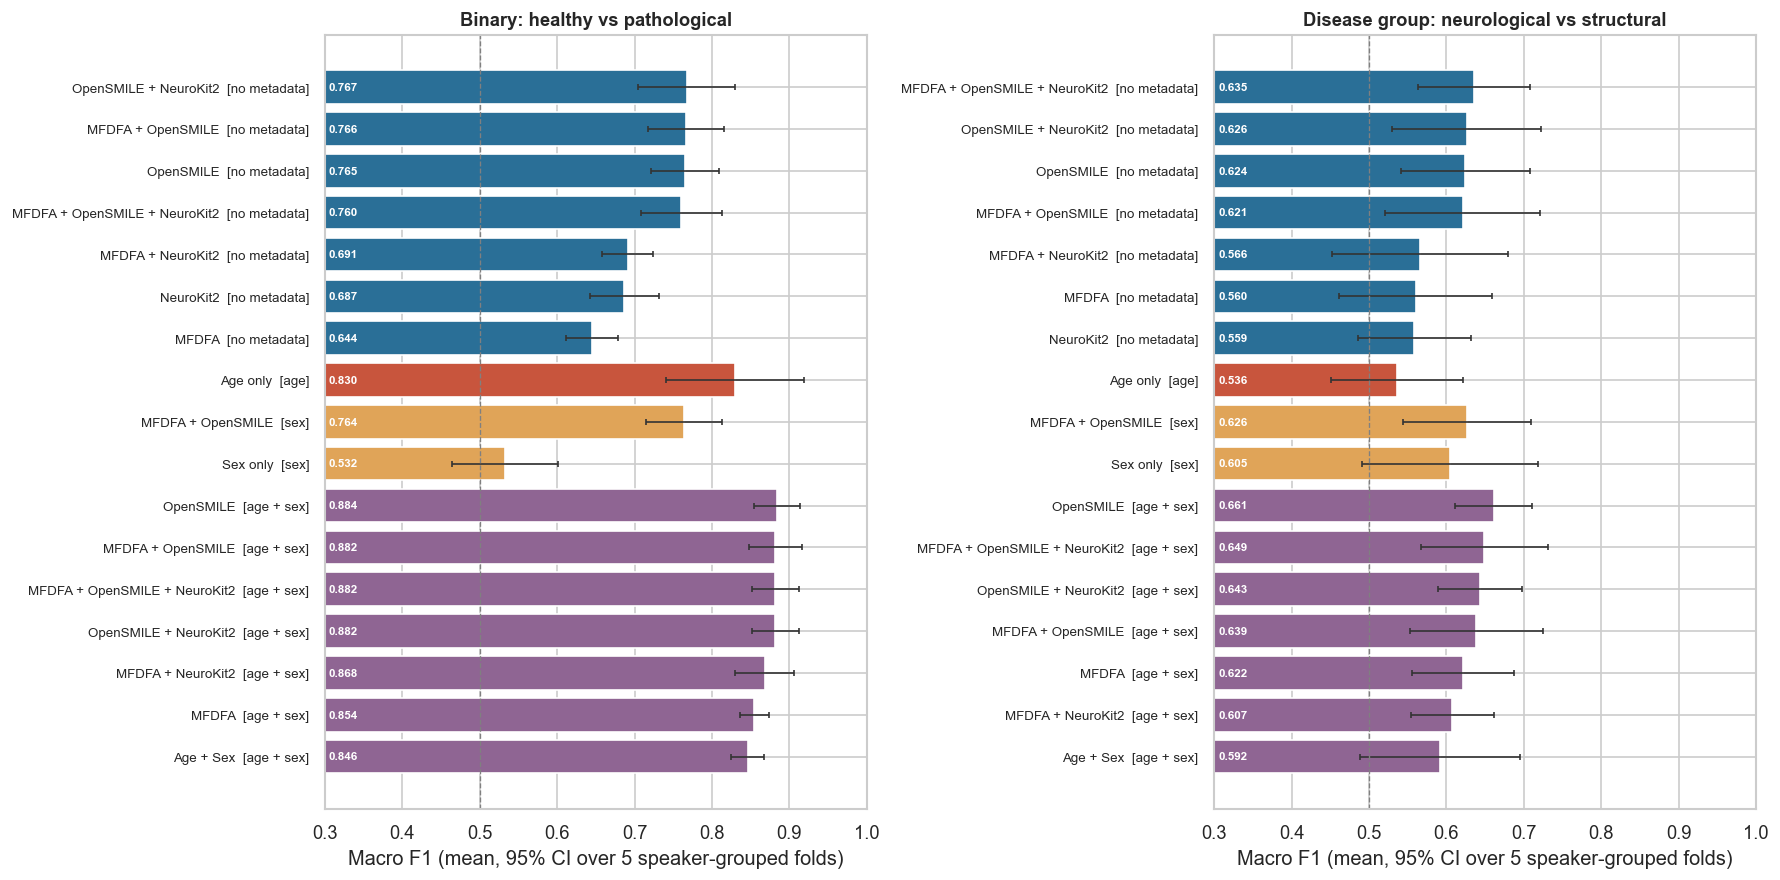

In [13]:
def plot_panel(ax, s, title):
    s = best_per_config(s).copy()
    s['_o'] = s.metadata.map(order)
    s = s.sort_values(['_o', 'f1_macro_mean'], ascending=[False, True])
    labels = [f"{c}  [{m}]" for c, m in zip(s.config, s.metadata)]
    colors = s.metadata.map({'no metadata': '#2a6f97', 'age': '#c8553d', 'sex': '#e0a458', 'age + sex': '#8f6593'})
    y = np.arange(len(s))
    ax.barh(y, s.f1_macro_mean, color=colors,
            xerr=[s.f1_macro_mean - s.f1_macro_ci_lo, s.f1_macro_ci_hi - s.f1_macro_mean],
            error_kw={'elinewidth': 1, 'capsize': 2, 'ecolor': '#333'})
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0.5, ls='--', lw=0.8, c='grey')
    ax.set_xlim(0.3, 1.0); ax.set_xlabel('Macro F1 (mean, 95% CI over 5 speaker-grouped folds)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    for yi, v in zip(y, s.f1_macro_mean):
        ax.text(0.305, yi, f'{v:.3f}', va='center', fontsize=7, color='white', fontweight='bold')

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
plot_panel(axes[0], bin_sum[bin_sum.setting == 'full'], 'Binary: healthy vs pathological')
plot_panel(axes[1], multi_sum[multi_sum.setting == 'full'], 'Disease group: neurological vs structural')
fig.tight_layout()
fig.savefig(FIG_DIR / 'feature_ablation_v2.png', dpi=300)
plt.show()

## 13 — Export

In [14]:
bin_folds_all.to_csv(OUT_DIR / 'binary_folds.csv', index=False)
multi_folds_all.to_csv(OUT_DIR / 'multiclass_folds.csv', index=False)
bin_sum.to_csv(OUT_DIR / 'binary_summary.csv', index=False)
multi_sum.to_csv(OUT_DIR / 'multiclass_summary.csv', index=False)
protocol_df.to_csv(OUT_DIR / 'protocol_log.csv', index=False)
comp.to_csv(OUT_DIR / 'final_composition.csv')
print('Saved to', OUT_DIR.resolve())

Saved to G:\Projects\multifractal-speech-analysis\results\ablation_v2


## 14 — Key numbers for the paper

In [15]:
def get(s, setting, config, meta, model=None):
    q = s[(s.setting == setting) & (s.config == config) & (s.metadata == meta)]
    q = q[q.model == model] if model else q.sort_values('f1_macro_mean', ascending=False)
    r = q.iloc[0]
    return f"{r.f1_macro_mean:.3f} ± {r.f1_macro_sd:.3f}  [{r.f1_macro_ci_lo:.3f}, {r.f1_macro_ci_hi:.3f}]  ({r.model})"

print('BINARY (full set, best model)')
for cfg, meta in [('Age only', 'age'), ('Sex only', 'sex'), ('Age + Sex', 'age + sex'),
                  ('MFDFA', 'no metadata'), ('OpenSMILE', 'no metadata'), ('MFDFA + OpenSMILE', 'no metadata'),
                  ('OpenSMILE + NeuroKit2', 'no metadata'), ('MFDFA + OpenSMILE + NeuroKit2', 'no metadata'),
                  ('MFDFA', 'age + sex'), ('MFDFA + OpenSMILE', 'age + sex'), ('MFDFA + OpenSMILE', 'sex')]:
    print(f'  {cfg:32s} [{meta:11s}]  {get(bin_sum, "full", cfg, meta)}')
print('\nBINARY (age x sex matched, best model)')
for cfg, meta in [('Age + Sex', 'age + sex'), ('MFDFA', 'no metadata'), ('OpenSMILE', 'no metadata'),
                  ('MFDFA + OpenSMILE', 'no metadata'), ('MFDFA + OpenSMILE + NeuroKit2', 'no metadata')]:
    print(f'  {cfg:32s} [{meta:11s}]  {get(bin_sum, "age-sex matched", cfg, meta)}')
print('\nDISEASE GROUP (full set, best model)')
for cfg, meta in [('Age + Sex', 'age + sex'), ('MFDFA', 'no metadata'), ('MFDFA + OpenSMILE', 'no metadata'),
                  ('MFDFA + OpenSMILE + NeuroKit2', 'no metadata'), ('MFDFA + OpenSMILE + NeuroKit2', 'age + sex')]:
    print(f'  {cfg:32s} [{meta:11s}]  {get(multi_sum, "full", cfg, meta)}')

BINARY (full set, best model)
  Age only                         [age        ]  0.830 ± 0.072  [0.741, 0.919]  (LogReg)
  Sex only                         [sex        ]  0.532 ± 0.055  [0.464, 0.601]  (LogReg)
  Age + Sex                        [age + sex  ]  0.846 ± 0.017  [0.824, 0.868]  (XGBoost)
  MFDFA                            [no metadata]  0.644 ± 0.027  [0.611, 0.678]  (LogReg)
  OpenSMILE                        [no metadata]  0.765 ± 0.036  [0.721, 0.810]  (LightGBM)
  MFDFA + OpenSMILE                [no metadata]  0.766 ± 0.039  [0.717, 0.815]  (LightGBM)
  OpenSMILE + NeuroKit2            [no metadata]  0.767 ± 0.051  [0.705, 0.830]  (LightGBM)
  MFDFA + OpenSMILE + NeuroKit2    [no metadata]  0.760 ± 0.042  [0.709, 0.812]  (RandomForest)
  MFDFA                            [age + sex  ]  0.854 ± 0.015  [0.836, 0.873]  (XGBoost)
  MFDFA + OpenSMILE                [age + sex  ]  0.882 ± 0.028  [0.848, 0.916]  (XGBoost)
  MFDFA + OpenSMILE                [sex        ]  0.764